In [1]:
# Martin MacDonald
# Honours Project
# 2D Discrete Traffic Model

# Setup

In [2]:
#If pandas is not installed, uncomment this line.
# !pip install pandas

In [3]:
#Imports
import numpy as np
import matplotlib.pyplot as plt
import time
import pandas as pd
import csv
import io
from matplotlib.colors import ListedColormap
from queue import PriorityQueue
from PIL import Image, ImageDraw, ImageFont
from collections import deque

# Define classes

In [4]:
#Define the Car class, used to hold data about each car.
class Car:
    def __init__(self, car_id, position, goal):
        self.id = car_id
        self.start_position = position
        self.position = position
        self.goal = goal
        self.path = []
        self.wait_counter = 0
        self.total_distance_travelled = 0
        self.steps_taken = 0
        self.reached_goal = False
        self.stuck_counter = 0
        self.timed_out = False

#Define SimulationStats class, holds info about the simulation.
class SimulationStats:
    def __init__(self, algorithm_name):
        self.algorithm_name = algorithm_name
        self.start_time = None
        self.end_time = None
        self.total_timesteps = 0
        self.cars_reached_goal = 0
        self.total_cars = 0

        #Track stats per car.
        self.car_stats = {}

        #Track algorithm performance.
        self.total_path_calculations = 0
        self.total_replans = 0
        self.total_steps_taken = 0
        self.total_distance_travelled = 0

        #Track grid events.
        self.congestion_events = 0
        
    #Marks start of simulation.
    def start_simulation(self):
        self.start_time = time.time()

    #Marks end of simulation.
    def end_simulation(self):
        self.end_time = time.time()

    #Get total computation time in seconds.
    def get_computation_time(self):
        if self.start_time and self.end_time:
            return self.end_time - self.start_time
        else:
            return 0

    #Record the statistics for a completed car.
    def record_car_completion(self, car):
        optimal_distance = manhattan_distance(car.start_position, car.goal)

        self.car_stats[car.id] = {
            'steps_taken': car.steps_taken,
            'distance_travelled': car.total_distance_travelled,
            'optimal_distance': optimal_distance,
            'wait_time': car.steps_taken - car.total_distance_travelled,
            'reached_goal': car.reached_goal,
            'path_efficiency': car.total_distance_travelled / optimal_distance if optimal_distance > 0 else 1.0
        }

    ### Increment each variable.
    def record_replan(self):
        self.total_replans += 1

    def record_congestion(self):
        self.congestion_events += 1

    def record_path_calculation(self):
        self.total_path_calculations += 1

    def record_timestep(self):
        self.total_timesteps += 1

    def record_steps_taken(self):
        self.total_steps_taken += 1

    def record_distance_travelled(self):
        self.total_distance_travelled += 1

    
    def calculate_summary(self, cars):
        self.total_cars = len(cars)
        self.cars_reached_goal = sum(1 for car in cars.values() if car.reached_goal)

        #Record statisitcs for each car.
        for car in cars.values():
            self.record_car_completion(car)

        #Only find averages for successful cars.
        successful_cars = [stats for stats in self.car_stats.values() if stats['reached_goal']]
                
        if successful_cars:
            average_steps = sum(s['steps_taken'] for s in successful_cars) / len(successful_cars)
            average_distance = sum(s['distance_travelled'] for s in successful_cars) / len(successful_cars)
            average_efficiency = sum(s['path_efficiency'] for s in successful_cars) / len(successful_cars)
            average_wait = sum(s['wait_time'] for s in successful_cars) / len(successful_cars)
        else:
            average_steps = average_distance = average_efficiency = average_wait = 0

        return {
            'algorithm': self.algorithm_name,
            'computation_time': self.get_computation_time(),
            'total_timesteps': self.total_timesteps,
            'success_rate': self.cars_reached_goal / self.total_cars if self.total_cars > 0 else 0,
            'cars_reached_goal': self.cars_reached_goal,
            'total_cars': self.total_cars,
            'total_replans': self.total_replans,
            'total_steps_taken': self.total_steps_taken,
            'total_distance_travelled': self.total_distance_travelled,
            'total_path_calculations': self.total_path_calculations,
            'congestion_events': self.congestion_events,
            'average_steps_taken': average_steps,
            'average_distance_travelled': average_distance,
            'average_path_efficiency': average_efficiency,
            'average_wait_time': average_wait
        }

    #Print a summary of the simulation.
    def print_summary(self, cars):

        summary = self.calculate_summary(cars)
        
        print(f'SIMULATION STATISTICS FOR {self.algorithm_name}')
        print(f'Computation time = {summary['computation_time']:.3f} seconds')
        print(f'Total timesteps = {summary['total_timesteps']}')
        print(f'Success rate = {summary['success_rate'] * 100:.1f} % ({summary['cars_reached_goal']} / {summary['total_cars']})')
        print()
        print('TOTALS')
        print(f'Total path calculations = {summary['total_path_calculations']}')
        print(f'Total replans = {summary['total_replans']}')
        print(f'Total steps taken = {summary['total_steps_taken']}')
        print(f'Total distance travelled = {summary['total_distance_travelled']}')
        print(f'Total Congestion events = {summary['congestion_events']}')
        print()
        print('AVERAGES')
        print(f'Average path efficiency = {summary['average_path_efficiency']:.3f}')
        print(f'Average steps taken = {summary['average_steps_taken']:.1f}')
        print(f'Average distance travelled = {summary['average_distance_travelled']:.1f}')
        print(f'Average wait time = {summary['average_wait_time']:.1f} timesteps')

## Setup the grid

In [5]:
#Setup grid.
def setup_grid(num_cars, rows, columns, obstacle_type = 10, num_obstacles = 5, cluster_size = 10, road_width = 2):
    total_size = rows * columns
    grid = np.zeros((rows, columns), dtype=np.int16)

    #Sets the grid up according to which type of obstacle is selected.
    if obstacle_type == 'Random':
        grid = add_random_obstacles(grid, rows, columns, num_obstacles)
    elif obstacle_type == 'Clusters':
        grid = add_obstacle_clusters(grid, rows, columns, num_obstacles, cluster_size)
    elif obstacle_type == 'Walls':
        grid = add_obstacle_walls(grid, rows, columns)
    elif obstacle_type == 'Blocks':
        grid = add_obstacle_city_blocks(grid, rows, columns, num_obstacles, road_width)
    
    
    #Ensure there are not more cars than the total size of the grid, throw a value error if there are.
    if num_cars > total_size:
        raise ValueError("There are too many cars for the size of the grid")
    
    #Cars dictionary which holds each car, its ID, positon & goal.
    cars = {}
    
    #Generates a randomly positioned car, checks if that space is already occupied, if it is, try again, 
    #if not, add car to grid & dictionary and give it a unique ID.
    car_id = 1
    used_goals = set()
    
    while car_id <= num_cars:
        #Generate random position
        row = np.random.randint(0, rows)
        col = np.random.randint(0, columns)
        #Check if the car can spawn on unoccupied space.
        if grid[row, col] == 0:
            goal_row = np.random.randint(0, rows)
            goal_column = np.random.randint(0, columns)
            #Check if the newly created goal has been used before or if it is the same position as the newly generated car. If it is, re-generate a new goal until sufficient.
            while (goal_row, goal_column) in used_goals or (goal_row, goal_column) == (row, col) or grid[goal_row, goal_column] == -1:
                goal_row = np.random.randint(0, rows)
                goal_column = np.random.randint(0, columns)
            #Add that newly created goal to used_goals
            used_goals.add((goal_row, goal_column))
            #If the space is clear, add that car to cars dictionary & grid and increment car_id by 1.
            grid[row, col] = car_id
            cars[car_id] = Car(car_id, (row, col), (goal_row, goal_column))
            car_id += 1

    return grid, cars

# Pathfinding functions

## Heuristic

In [6]:
#Manhattan Distance
def manhattan_distance(position_1, position_2):
    return (abs(position_1[0] - position_2[0]) + abs(position_1[1] - position_2[1]))

## Get Neighbours

In [7]:
#Get neighbours for a given position.
def get_neighbours(position, rows, columns):
    #Get the current cars position and split it into row and column.
    row, column = position
    #Setup a list to contain neighbours.
    neighbours = []

    #Create a list of tuples which represent each cardinal direction/possible move
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    #For each direction, get the new position when taking that direction into account. 
    #If that position would be off the side of the grid, don't append it to the neighbours list.
    for delta_row, delta_column in directions:
        new_row, new_column = row + delta_row, column + delta_column

        if 0 <= new_row < rows and 0 <= new_column < columns:
            neighbours.append((new_row, new_column))

    #Return all the valid neighbours of the current car. 
    return neighbours

## Reconstruct path

In [8]:
#Reconstruct the path from start to goal using came_from.
def reconstruct_path(came_from, start, goal):
    #Set the current position to goal.
    current = goal
    #Setup a list to contain the path.
    path = []

    #While current has not reached the start, add the current step to the path 
    #then set current to its parent step (the next step along on the way to start).
    while current != start:
        path.append(current)
        current = came_from[current]

    #Add the start to the path.
    path.append(start)
    #Reverse the path list so it can be followed along as start -> goal, rather than goal -> start which it was.
    path.reverse()
    #Return the newly created path.
    return path

# Obstacle types

## Add random obstacles

In [9]:
def add_random_obstacles(grid, rows, columns, num_obstacles):
    obstacles_placed = 0

    #Attempts to place down objects at random.
    while obstacles_placed < num_obstacles:
        row = np.random.randint(0, rows)
        column = np.random.randint(0, columns)

        if grid[row, column] == 0:
            grid[row, column] = -1
            obstacles_placed += 1

    return grid

## Add cluster obstacles

In [10]:
def add_obstacle_clusters(grid, rows, columns, num_obstacles, cluster_size = 10):
    for i in range(num_obstacles):
        #Choose a random centre for the cluster.
        centre_row = np.random.randint(2, rows - 2)
        centre_column = np.random.randint(2, columns - 2)

        #Extending from the clusters centre, spawn obstacles based on the given cluster_size.
        for j in range(cluster_size):
            offset_row = np.random.randint(-2, 3)
            offset_column = np.random.randint(-2, 3)

            obstacle_row = centre_row + offset_row
            obstacle_column = centre_column + offset_column

            #Ensure the obstacle is created on the grid and isn't overlapping anything else.
            if (0 <= obstacle_row < rows and 0 <= obstacle_column < columns and grid[obstacle_row, obstacle_column] == 0):
                grid[obstacle_row, obstacle_column] = -1

    return grid

## Add wall obstacles

In [11]:
def add_obstacle_walls(grid, rows, columns):
    #Add a column of obstacles with occasional gaps.
    wall_column = columns // 2

    for row in range(rows):
        if row % 5 != 0:
            grid[row, wall_column] = -1

    #Add a row of obstacles with occasional gaps.
    wall_row = rows // 2

    for column in range(columns):
        if column % 5 != 0:
            grid[wall_row, column] = -1

    #Ensure middle space is filled in otherwise cars may spawn and get trapped.
    grid[rows // 2, columns // 2] = -1

    return grid

## Add city blocks obstacles

In [12]:
def add_obstacle_city_blocks(grid, rows, columns, block_size, road_width = 2):
    #Create a block of obstacles with roads running down them, these roads are left as 0 in the grid so that cars may enter them.
    for row in range(0, rows, block_size + road_width):
        for column in range(0, columns, block_size + road_width):
            for r in range(row, min(row + block_size, rows)):
                for c in range(column, min(column + block_size, columns)):
                    grid[r, c] = -1
    return grid

# Pathfinding algorithms

## Breadth-First Search algorithm

In [13]:
def breadth_first_search(grid, start, goal, rows, columns, car_id):
    #Setup the frontier as a regular queue.
    frontier = deque([start])
    came_from = {}
    came_from[start] = None

    #While there are still grid spaces to explore, continue searching.
    while frontier:
        current = frontier.popleft()

        #Check if the goal has been reached.
        if current == goal:
            return reconstruct_path(came_from, start, goal)

        #Explore each valid neighbour.
        for neighbour in get_neighbours(current, rows, columns):
            #If the neighbour is occupied or invalid, skip.
            if (grid[neighbour[0], neighbour[1]] == -1 or (grid[neighbour[0], neighbour[1]] != 0 and grid[neighbour[0], neighbour[1]] != car_id and neighbour != goal)):
                continue

            #Ensure that each node is only visited once.
            if neighbour not in came_from:
                frontier.append(neighbour)
                came_from[neighbour] = current

    #Return an empty list if no path is found.
    return []

## Dijkstra's algorithm

In [14]:
def dijkstra(grid, start, goal, rows, columns, car_id):
    #Setup the frontier as a priority queue. A priority queue is a queue where each item 
    #in the queue can be given a different priority, meaning that higher priority items are 
    #dequeued first.
    frontier = PriorityQueue()
    #Add the start to the queue, give it a priority of 0.
    frontier.put((0, start))

    came_from = {}
    cost_so_far = {}

    #Setup dictionaries to contain came from and cost so far.
    came_from[start] = None
    cost_so_far[start] = 0

    #While the frontier is not empty, continue to search.
    while not frontier.empty():
        #Only get the current value from the queue, as we don't need the priority value, discard it.
        _, current = frontier.get()

        #Check if the goal has been reached.
        if current == goal:
            return reconstruct_path(came_from, start, goal)

        #Explore each valid neighbour of the current position of the frontier.
        for neighbour in get_neighbours(current, rows, columns):
            #Skip if the neighbour is occupied by a car or obstacle, unless it's the goal.
            if (grid[neighbour[0], neighbour[1]] == -1 or (grid[neighbour[0], neighbour[1]] != 0 and grid[neighbour[0], neighbour[1]] != car_id and neighbour != goal)):
                continue

            #Calculate the new cost, each move costs 1.
            new_cost = cost_so_far[current] + 1

            #If this is a new position or a cheaper path to this position has been found, update the frontier. 
            if neighbour not in cost_so_far or new_cost < cost_so_far[neighbour]:
                cost_so_far[neighbour] = new_cost
                #The priority is ONLY the cost, there is no heuristic like A*.
                priority = new_cost
                frontier.put((priority, neighbour))
                came_from[neighbour] = current

    #Return an empty list if no path could be found.
    return []

## A Star algorithm

In [15]:
#A Star algorithm
def a_star(grid, start, goal, rows, columns, car_id):
    #Setup the frontier as a priority queue. A priority queue is a queue where each item 
    #in the queue can be given a different priority, meaning that higher priority items are 
    #dequeued first.
    frontier = PriorityQueue()
    #Add the start to the queue, give it a priority of 0.
    frontier.put((0, start))

    #Setup dictionaries to contain came from and cost so far.
    came_from = {}
    cost_so_far = {}

    #Initialise their start position to be none (no parent yet) and 0 (no cost yet).
    came_from[start] = None
    cost_so_far[start] = 0

    #While the frontier is not empty, continue to search.
    while not frontier.empty():
        #Only get the current value from the queue, as we don't need the priority value, discard it.
        _, current = frontier.get()

        #Check if the goal has been reached.
        if current == goal:
            return reconstruct_path(came_from, start, goal)

        #Explore each valid neighbour of the current position of the frontier.
        for neighbour in get_neighbours(current, rows, columns):
            #Skip if the neighbour is occupied by a car or obstacle, unless it's the goal.
            if (grid[neighbour[0], neighbour[1]] == -1 or (grid[neighbour[0], neighbour[1]] != 0 and grid[neighbour[0], neighbour[1]] != car_id and neighbour != goal)):
                continue

            #Calculate the new cost, each move costs 1.
            new_cost = cost_so_far[current] + 1

            #If this is a new position or a cheaper path to this position has been found, update the frontier. 
            if neighbour not in cost_so_far or new_cost < cost_so_far[neighbour]:
                cost_so_far[neighbour] = new_cost
                #The priority is the actual cost added to the estimated cost to the goal.
                priority = new_cost + manhattan_distance(neighbour, goal)
                frontier.put((priority, neighbour))
                came_from[neighbour] = current
    #Return an empty list if no path could be found.
    return []

## Greedy best-first algorithm

In [16]:
def greedy_best_first(grid, start, goal, rows, columns, car_id):
    
    frontier = PriorityQueue()
    frontier.put((0, start))

    came_from = {}
    came_from[start] = None


    #While the frontier is not empty, continue to search.
    while not frontier.empty():
        #Only get the current value from the queue, as we don't need the priority value, discard it.
        _, current = frontier.get()

        #Check if goal has been reached.
        if current == goal:
            return reconstruct_path(came_from, start, goal)

        for neighbour in get_neighbours(current, rows, columns):
            #Skip if the neighbour is occupied by a car or obstacle, unless it's the goal.
            if (grid[neighbour[0], neighbour[1]] == -1 or (grid[neighbour[0], neighbour[1]] != 0 and grid[neighbour[0], neighbour[1]] != car_id and neighbour != goal)):
                continue

            #Only visit each node once, greedy means that only the first path found is the one used.
            if neighbour not in came_from:
                #Priority only uses the heuristic, no cost is used.
                priority = manhattan_distance(neighbour, goal)
                frontier.put((priority, neighbour))
                came_from[neighbour] = current

    #Return an empty list if no path could be found.
    return []

# Simulation

## Create GIF

In [17]:
#Create a snapshot of the current state of the grid.
def create_snapshot(grid, cars, rows, columns, timestep, algorithm, obstacle_type, cell_size=20):

    algorithms = {
        'AStar': 'A*',
        'BFS': 'Breadth-first search',
        'Dijkstra': "Dijkstra's",
        'Greedy': 'Greedy best-first search'
    }

    # Calculate frame dimensions.
    image_width = columns * cell_size
    image_height = rows * cell_size + 50  
    
    # Create frame.
    image = Image.new('RGB', (image_width, image_height), color='white')
    draw = ImageDraw.Draw(image)
    
    # Draw cells on grid.
    for row in range(rows):
        for column in range(columns):
            x1 = column * cell_size
            y1 = row * cell_size + 50  
            x2 = x1 + cell_size
            y2 = y1 + cell_size
            
            cell_value = grid[row, column]
            
            if cell_value == 0:
                # Empty cell = light grey.
                colour = (240, 240, 240)
            elif cell_value == -1:
                colour = (50, 50, 50)
            else:
                # Different colour for each car.
                colours = [
                    #Red
                    (255, 100, 100), 
                    #Blue
                    (0, 255, 255), 
                    #Green
                    (100, 255, 100), 
                    #Yellow
                    (255, 255, 100), 
                    #Pink
                    (255, 100, 255),  
                ]
                #Decide the colour of the given cell.
                colour = colours[(cell_value - 1) % len(colours)]
            
            # Draw cell.
            draw.rectangle([x1, y1, x2, y2], fill=colour, outline='black', width=1)
            
            # Draw car ID.
            if cell_value > 0:
                text_x = x1 + cell_size // 2
                text_y = y1 + cell_size // 2
                draw.text((text_x, text_y), str(cell_value), fill='black', anchor='mm')
    
    # Draw goals as circles.
    for car in cars.values():
        goal_row, goal_column = car.goal
        x = goal_column * cell_size + cell_size // 2
        y = goal_row * cell_size + cell_size // 2 + 50
        radius = cell_size // 4
        
        # Draw goal marker.
        draw.ellipse(
            [x - radius, y - radius, x + radius, y + radius],
            outline='red',
            width=3
        )
    
    # Draw timestep information.
    cars_at_goal = sum(1 for c in cars.values() if c.reached_goal)
    
    # Try to load arial bold font.
    try:
        font_bold = ImageFont.truetype("arialbd.ttf", 16)
    except:
        try:
            # Try other arial bold if that doesn't work.
            font_bold = ImageFont.truetype("Arial Bold.ttf", 16)
        except:
            font_bold = ImageFont.load_default()
            
    algorithm_name = algorithms[algorithm]
    
    # Centre algorithm name at the top.
    algorithm_text = f"Algorithm: {algorithm_name}"
    bbox = draw.textbbox((0, 0), algorithm_text, font=font_bold)
    text_width = bbox[2] - bbox[0]
    centre_x = (image_width - text_width) // 2
    draw.text((centre_x, 10), algorithm_text, fill='black', font=font_bold)
    
    # Centre timestep and cars at goal info below.
    timestep_text = f"Timestep: {timestep} | Cars at goal: {cars_at_goal}/{len(cars)} | Obstacle type: {obstacle_type}"
    bbox = draw.textbbox((0, 0), timestep_text, font=font_bold)
    text_width = bbox[2] - bbox[0]
    centre_x = (image_width - text_width) // 2
    draw.text((centre_x, 30), timestep_text, fill='black', font=font_bold)
    
    return image

In [18]:
#Save all frames as a GIF.
def save_frames_as_gif(frames, filename='traffic_simulation.gif', duration=200):
    if frames:
        frames[0].save(
            filename,
            save_all=True,
            append_images=frames[1:],
            duration=duration,
            loop=0
        )
        print(f"GIF saved as {filename}")

## Update simulation

In [19]:
def update_simulation(grid, cars, rows, columns, algorithm, max_wait = 3, max_stuck = 30, stats = None):

    algorithms = {
        'AStar': a_star,
        'BFS': breadth_first_search,
        'Dijkstra': dijkstra,
        'Greedy': greedy_best_first
    }

    for car in cars.values():

        old_position = car.position
        
        #If the car has not reached goal, increment steps taken by 1.
        if not car.reached_goal:
            car.steps_taken += 1
            if stats:
                stats.record_steps_taken()
            
        #If current car has reached goal, skip to the next car.
        if car.reached_goal:
            continue

        #If the car doesn't have a path, calculate one using the provided algorithm.
        if not car.path:
            car.path = algorithms[algorithm](grid, car.position, car.goal, rows, columns, car.id)
            if stats:
                stats.record_path_calculation()
            #If the car still doesn't have a path after re-calculation, increase its stuck_counter by 1 and continue to next car.
            if not car.path:
                car.stuck_counter += 1

                if car.stuck_counter >= max_stuck:
                    car.timed_out = True
                    
                continue

        #If there is still path remaining for the car to traverse, attempt to move to the next step.
        if len(car.path) > 1:
            
            #Set next position to the next step along the path.
            next_position = car.path[1]

            #If the next position is free, move the car to that position, remove the current position from the path, reset wait counter to zero and increment total distance and steps taken by 1.
            if grid[next_position[0], next_position[1]] == 0:
                grid[car.position[0], car.position[1]] = 0
                car.position = next_position
                grid[next_position[0], next_position[1]] = car.id
                car.path.pop(0)
                car.wait_counter = 0
                car.stuck_counter = 0
                car.total_distance_travelled += 1
                if stats:
                    stats.record_distance_travelled()
                

                #If the car's new position is its goal, print a message and set its reached_goal boolean to True.
                if car.position == car.goal:
                    car.reached_goal = True

            #If the next space is occupied by another car/object, increment the wait counter and congestion event by 1.
            else:
                car.wait_counter += 1
                if stats:
                    stats.record_congestion()

                #If the space is still occupied after the max amount of waits has been reached, recalculate the path by running the provided algorithm again.
                if car.wait_counter >= max_wait:
                    car.path = algorithms[algorithm](grid, car.position, car.goal, rows, columns, car.id)
                    car.wait_counter = 0
                    if stats:
                        stats.record_replan()
                        stats.record_path_calculation()

        if car.position == old_position and not car.reached_goal and not car.timed_out:
            car.stuck_counter += 1

            if car.stuck_counter >= max_stuck:
                    car.timed_out = True

        elif car.position != old_position:
            car.stuck_counter = 0 

## Run Simulation

In [20]:
#Run sim and create a gif
def run_simulation(num_cars, rows, columns, algorithm, obstacle_type = None, num_obstacles = 5, cluster_size = 10, road_width = 2, max_timesteps=200, max_wait=3, max_stuck = 30):

    stats = SimulationStats(algorithm)
    stats.start_simulation()
    
    frames = []
    grid, cars = setup_grid(num_cars, rows, columns, obstacle_type, num_obstacles, cluster_size)
    print("Running simulation")
    
    for timestep in range(max_timesteps):
        # Capture frame before updating.
        frame = create_snapshot(grid, cars, rows, columns, timestep, algorithm, obstacle_type)
        frames.append(frame)
        
        # Update simulation.
        update_simulation(grid, cars, rows, columns, algorithm, max_wait, max_stuck, stats)
        stats.record_timestep()
        
        # Print progress every 20 steps.
        if timestep % 20 == 0:
            cars_at_goal = sum(1 for c in cars.values() if c.reached_goal)
            print(f"Timestep {timestep}: {cars_at_goal}/{len(cars)} cars at goal.")
        
        # Check if all cars have reached their goals.
        if all(car.reached_goal or car.timed_out for car in cars.values()):
            successful_cars = sum(1 for c in cars.values() if c.reached_goal)
            timed_out_cars = sum(1 for c in cars.values() if c.timed_out)
            print(f"\nSimulation ended at timestep {timestep}:")
            print(f"  {successful_cars} cars reached their goals")
            print(f"  {timed_out_cars} cars timed out")
            
            
            # Add 5 seconds of freeze frames at the end
            final_frame = create_snapshot(grid, cars, rows, columns, timestep, algorithm, obstacle_type)
            #Append the final frame, otherwise it won't appear in the GIF.
            frames.append(final_frame)

            #Adds 50 copies of the final frame to add the 5 secs of freeze frame to the end.
            for _ in range(50):
                frames.append(final_frame)
            break
    
    # If simulation didn't complete, still freeze at the end.
    else:
        final_frame = create_snapshot(grid, cars, rows, columns, max_timesteps - 1, algorithm, obstacle_type)
        for _ in range(50):
            frames.append(final_frame)

    #End statistics tracking and calculate them.
    stats.end_simulation()
    summary = stats.calculate_summary(cars)
    
    # Save GIF.
    if obstacle_type is not None:
        save_frames_as_gif(frames, f'{algorithm}_obst_traffic_sim.gif', duration=100)
    else:
        save_frames_as_gif(frames, f'{algorithm}_traffic_sim.gif', duration=100)
    
    # Print final statistics.
    print("\n=== Final Statistics ===")
    stats.print_summary(cars)
    
    return frames, stats, summary

In [21]:
'''
Run the simulation

Possible parameters are: num_cars, rows, columns, algorithm, obstacle_type (OPTIONAL), num_obstacles (OPTIONAL),
                         cluster_size (OPTIONAL), road_width (OPTIONAL), max_timesteps (OPTIONAL), max_wait (OPTIONAL).

For algorithm, the options are: 
AStar - A* Algorithm, generally the fastest.
BFS - Breadth first search, cars tend to get stuck. 
Dijkstra - Dijkstra's algorithm, sometimes fast, cars tend to get stuck.
Greedy - Greedy best-first search, sometimes very fast, sometimes significantly slower.

For obstacle_type, the options are:
Random - Creates randomly generated obstacles.
Clusters - Creates clusters of obstacles.
    cluster_size - Changes how big each cluster is | Default = 10.
Walls - Adds 4 walls with gaps which span the cardinal directions.
Blocks - Adds city blocks with streets cars can go down. num_obstacles is treated as block_size here.
    road_width - Defines how big a road is | Default = 2
'''
frames, stats, summary = run_simulation(num_cars = 50, 
                                        rows = 30, 
                                        columns = 30, 
                                        algorithm = 'AStar',
                                        obstacle_type = 'Blocks')

Running simulation
Timestep 0: 0/50 cars at goal.
Timestep 20: 10/50 cars at goal.
Timestep 40: 14/50 cars at goal.
Timestep 60: 24/50 cars at goal.
Timestep 80: 32/50 cars at goal.
Timestep 100: 41/50 cars at goal.
Timestep 120: 46/50 cars at goal.

Simulation ended at timestep 131:
  50 cars reached their goals
  0 cars timed out
GIF saved as AStar_obst_traffic_sim.gif

=== Final Statistics ===
SIMULATION STATISTICS FOR AStar
Computation time = 1.565 seconds
Total timesteps = 132
Success rate = 100.0 % (50 / 50)

TOTALS
Total path calculations = 443
Total replans = 188
Total steps taken = 3185
Total distance travelled = 2387
Total Congestion events = 653

AVERAGES
Average path efficiency = 2.505
Average steps taken = 63.7
Average distance travelled = 47.7
Average wait time = 16.0 timesteps


# Data analysis

## Single algorithm analysis

In [22]:
def run_multiple_trials(num_trials = 10, num_cars = 50, rows = 30, columns = 30, algorithm = 'AStar', obstacle_type = 'None', num_obstacles = 5, 
                        cluster_size = 10, road_width = 2, max_timesteps = 200, max_wait = 3, max_stuck = 30):

    results = []

    print(f'Running {num_trials} trials with {algorithm}')

    #Run trials as many times as num_trials.
    for trial_num in range(num_trials):
        print(f'Trial {trial_num + 1}/{num_trials}')

        #Set unique seed for this trial.
        np.random.seed(trial_num)

        #Setup stats for the sim.
        stats = SimulationStats(algorithm)
        stats.start_simulation()

        #Setup the grid.
        grid, cars = setup_grid(num_cars, rows, columns, obstacle_type, num_obstacles, cluster_size)

        #Run sim.
        for timestep in range(max_timesteps):
            update_simulation(grid, cars, rows, columns, algorithm, max_wait, max_stuck, stats)
            stats.record_timestep()

            if all(car.reached_goal or car.timed_out for car in cars.values()):
                break

        #End sim and save stats as summary.
        stats.end_simulation()
        summary = stats.calculate_summary(cars)
        summary['trial'] = trial_num + 1
        results.append(summary)

    print(f'Completed {num_trials} trials')

    return results

In [23]:
def analyse_single_algorithm_results(results):
    
    #Setup dataframe.
    df = pd.DataFrame(results)

    print(f'Analysis: {results[0]['algorithm']} ({len(results)} trials')

    #Key metrics to be analysed.
    metrics = {
        'Success Rate': ('success_rate', lambda x: x * 100),
        'Avg Steps': ('average_steps_taken', lambda x: x),
        'Avg Distance': ('average_distance_travelled', lambda x: x),
        'Avg Path Efficiency': ('average_path_efficiency', lambda x: x),
        'Avg Wait Time': ('average_wait_time', lambda x: x),
        'Computation Time': ('computation_time', lambda x: x),
        'Total Replans': ('total_replans', lambda x: x),
        'Congestion Events': ('congestion_events', lambda x: x)
    }

    print(f"{'Metric':<30} {'Mean':<12} {'Std Dev':<12} {'Min':<12} {'Max':<12}")

    #Get values, mean, standard deviation, min value, max value in total.
    for metric_name, (column, transform) in metrics.items():
        values = df[column].apply(transform)
        mean_val = values.mean()
        std_val = values.std()
        min_val = values.min()
        max_val = values.max()

        if 'Rate' in metric_name or 'Efficiency' in metric_name:
            print(f"{metric_name:<25} {mean_val:>11.2f} {std_val:>11.2f} {min_val:>11.2f} {max_val:>11.2f}")
        elif 'Time' in metric_name:
            print(f"{metric_name:<25} {mean_val:>11.3f} {std_val:>11.3f} {min_val:>11.3f} {max_val:>11.3f}")
        else:
            print(f"{metric_name:<25} {mean_val:>11.1f} {std_val:>11.1f} {min_val:>11.1f} {max_val:>11.1f}")

    #Save data to CSV.
    filename = f"{results[0]['algorithm']}_multiple_trials.csv"
    df.to_csv(filename, index=False)
    print(f"\nResults saved to {filename}")
    
    return df

In [24]:
def visualise_single_algorithm_results(results):

    #Visualise data as charts.
    algorithm_name = results[0]['algorithm']
    num_trials = len(results)
    num_cars = results[0]['total_cars']

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle(f'{algorithm_name} Performance Across {num_trials} Trials with {num_cars} cars.', 
                 fontsize=16, fontweight='bold')

    trials = [r['trial'] for r in results]
    success_rates = [r['success_rate'] * 100 for r in results]
    avg_steps = [r['average_steps_taken'] for r in results]
    avg_efficiency = [r['average_path_efficiency'] for r in results]
    computation_times = [r['computation_time'] for r in results]
    total_replans = [r['total_replans'] for r in results]
    congestion_events = [r['congestion_events'] for r in results]

    ax = axes[0, 0]
    ax.plot(trials, success_rates, marker='o', linewidth=2, markersize=8, color='skyblue')
    ax.axhline(y=np.mean(success_rates), color='r', linestyle='--', 
               label=f'Mean: {np.mean(success_rates):.1f}%', linewidth=2)
    ax.set_xlabel('Trial')
    ax.set_ylabel('Success Rate (%)')
    ax.set_title('Success Rate per Trial')
    ax.set_ylim(0, 110)
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[0, 1]
    ax.plot(trials, avg_steps, marker='o', linewidth=2, markersize=8, color='lightgreen')
    ax.axhline(y=np.mean(avg_steps), color='r', linestyle='--', 
               label=f'Mean: {np.mean(avg_steps):.1f}', linewidth=2)
    ax.set_xlabel('Trial')
    ax.set_ylabel('Average Steps')
    ax.set_title('Average Steps to Completion per Trial')
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[0, 2]
    ax.plot(trials, avg_efficiency, marker='o', linewidth=2, markersize=8, color='coral')
    ax.axhline(y=np.mean(avg_efficiency), color='r', linestyle='--', 
               label=f'Mean: {np.mean(avg_efficiency):.3f}', linewidth=2)
    ax.axhline(y=1.0, color='g', linestyle=':', alpha=0.5, label='Optimal (1.0)')
    ax.set_xlabel('Trial')
    ax.set_ylabel('Path Efficiency')
    ax.set_title('Path Efficiency per Trial')
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1, 0]
    ax.plot(trials, computation_times, marker='o', linewidth=2, markersize=8, color='plum')
    ax.axhline(y=np.mean(computation_times), color='r', linestyle='--', 
               label=f'Mean: {np.mean(computation_times):.3f}s', linewidth=2)
    ax.set_xlabel('Trial')
    ax.set_ylabel('Time (seconds)')
    ax.set_title('Computation Time per Trial')
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1, 1]
    ax.plot(trials, total_replans, marker='o', linewidth=2, markersize=10, color='gold')
    ax.axhline(y=np.mean(total_replans), color='r', linestyle='--', 
               label=f'Mean: {np.mean(total_replans):.0f}', linewidth=2)
    ax.set_xlabel('Trial')
    ax.set_ylabel('Replanning Events')
    ax.set_title('Total Replanning Events per Trial')
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1, 2]
    ax.plot(trials, congestion_events, marker='o', linewidth=2, markersize=8, color='lightcoral')
    ax.axhline(y=np.mean(congestion_events), color='r', linestyle='--', 
               label=f'Mean: {np.mean(congestion_events):.0f}', linewidth=2)
    ax.set_xlabel('Trial')
    ax.set_ylabel('Congestion Events')
    ax.set_title('Total Congestion Events per Trial')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()

    filename = f'{algorithm_name}_trials_visualisation.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nVisualisation saved as '{filename}'")

Running 10 trials with AStar
Trial 1/10
Trial 2/10
Trial 3/10
Trial 4/10
Trial 5/10
Trial 6/10
Trial 7/10
Trial 8/10
Trial 9/10
Trial 10/10
Completed 10 trials
Analysis: AStar (10 trials
Metric                         Mean         Std Dev      Min          Max         
Success Rate                    94.00        9.66       80.00      100.00
Avg Steps                        23.6         3.9        18.8        31.1
Avg Distance                     22.6         3.1        18.5        28.3
Avg Path Efficiency              1.05        0.05        1.01        1.18
Avg Wait Time                   1.030       0.922       0.300       2.800
Computation Time                0.015       0.016       0.004       0.056
Total Replans                    24.8        38.5         1.0        95.0
Congestion Events                75.6       115.6         3.0       287.0

Results saved to AStar_multiple_trials.csv


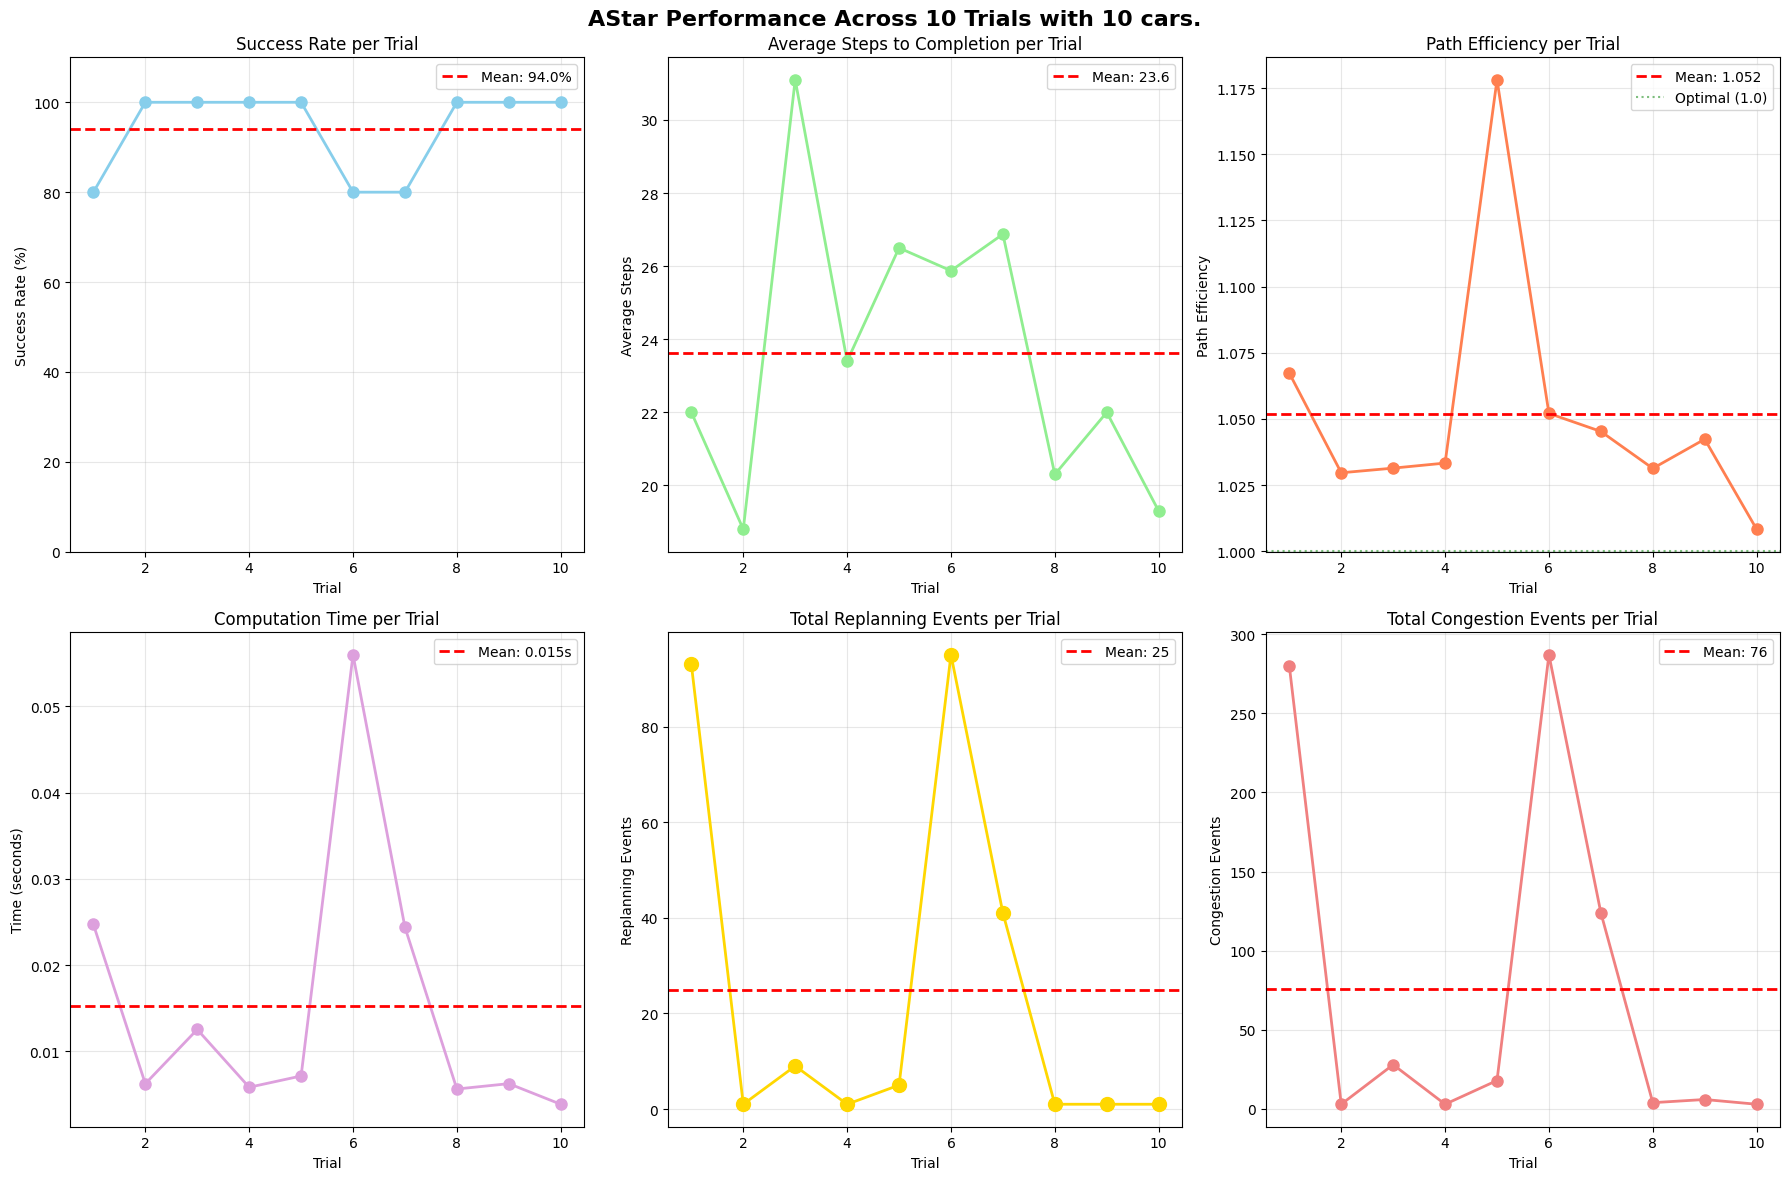


Visualisation saved as 'AStar_trials_visualisation.png'


In [25]:
results = run_multiple_trials(
    num_trials=10,
    num_cars=10,
    algorithm='AStar',
    obstacle_type='Clusters',
    num_obstacles=8
)
df = analyse_single_algorithm_results(results)

visualise_single_algorithm_results(results)

## Comparative analysis

In [26]:
def run_comparative_analysis(num_trials = 10, num_cars = 50, rows = 30, columns = 30, obstacle_type = 'Clusters', num_obstacles = 10, cluster_size = 10, road_width = 2, max_timesteps = 200, 
                             max_wait = 3, max_stuck = 30):
    #Algorithms to compare.
    algorithms = ['AStar', 'Dijkstra', 'BFS', 'Greedy']

    #Store results by algorithm name.
    results_by_algorithm = {name: [] for name in algorithms}

    print(f'Comparative analysis: {num_trials} trials with {num_cars} cars each')

    for trial_num in range(num_trials):
        print(f'Trial {trial_num + 1}/{num_trials}')

        #Maintain the same seed for all tests, this means the grid will remain the same, makes it more reproducible.
        np.random.seed(trial_num)

        #Setup grid.
        original_grid, original_cars = setup_grid(num_cars, rows, columns, obstacle_type, num_obstacles, cluster_size, road_width)
        original_grid_clean = original_grid.copy()

        #Save the initial car configurations.
        initial_car_configs = []
        for car in original_cars.values():
            initial_car_configs.append({
                'id':car.id,
                'start':car.start_position,
                'goal':car.goal
            })

        print('Grid created')

        for algorithm_name in algorithms:
            print(f'Testing {algorithm_name}')

            #Copys of the original grid are copied for this algorithm.
            grid = np.copy(original_grid_clean)
            cars = {}

            #Setup grid and cars.
            for config in initial_car_configs:
                grid[config['start'][0], config['start'][1]] = config['id']
                cars[config['id']] = Car(config['id'], config['start'], config['goal'])
    
            stats = SimulationStats(algorithm_name)
            stats.start_simulation()

            #Run sim with stats.
            for timestep in range(max_timesteps):
                update_simulation(grid, cars, rows, columns, algorithm_name, max_wait, max_stuck, stats)
                stats.record_timestep()

                if all(car.reached_goal or car.timed_out for car in cars.values()):
                    break

            #End sim, summarise stats.
            stats.end_simulation()
            summary = stats.calculate_summary(cars)
            summary['trial'] = trial_num + 1
            results_by_algorithm[algorithm_name].append(summary)

    print('')
    print("Comparative analysis done")
    return results_by_algorithm, num_trials, num_cars

In [27]:
def analyse_comparative_results(results_by_algorithm, num_trials, num_cars):

    num_trials = num_trials
    num_cars = num_cars
    
    #Put results into a list.
    all_data = []
    for algorithm_name, trials in results_by_algorithm.items():
        for trial_result in trials:
            all_data.append(trial_result)

    #Read data into dataframe.
    df = pd.DataFrame(all_data)

    #Aggregate stats.
    print("Aggregate stats accross all trials")

    print(f"{'Algorithm':<17} {'Success%':<12} {'Avg Steps':<12} {'Efficiency':<15} "
          f"{'Wait Time':<12} {'Replans':<10} {'Time(s)':<10}")

    for algorithm in ['AStar', 'Dijkstra', 'BFS', 'Greedy']:
        algorithm_data = df[df['algorithm'] == algorithm]

        success_mean = algorithm_data['success_rate'].mean() * 100
        success_std = algorithm_data['success_rate'].std() * 100
        steps_mean = algorithm_data['average_steps_taken'].mean()
        steps_std = algorithm_data['average_steps_taken'].std()
        efficiency_mean = algorithm_data['average_path_efficiency'].mean()
        efficiency_std = algorithm_data['average_path_efficiency'].std()
        wait_mean = algorithm_data['average_wait_time'].mean()
        wait_std = algorithm_data['average_wait_time'].std()
        replans_mean = algorithm_data['total_replans'].mean()
        replans_std = algorithm_data['total_replans'].std()
        time_mean = algorithm_data['computation_time'].mean()
        time_std = algorithm_data['computation_time'].std()

        print(f"{algorithm:<15} "
              f"{success_mean:>5.1f} ± {success_std:<5.1f} "
              f"{steps_mean:>5.1f} ± {steps_std:<5.1f} "
              f"{efficiency_mean:>5.3f} ± {efficiency_std:<5.3f} "
              f"{wait_mean:>5.1f} ± {wait_std:<5.1f} "
              f"{replans_mean:>5.0f} ± {replans_std:<4.0f} "
              f"{time_mean:>5.3f} ± {time_std:<4.3f}")

    #Best performances by metric.
    print("Best perfomance per metric")
    print('')

    #Group by trial.
    num_trials = max(d['trial'] for d in all_data)
        
    metrics_to_check = [
    ('success_rate', 'Success Rate', 'max'),
    ('average_path_efficiency', 'Path Efficiency (lower is better)', 'min'),
    ('average_steps_taken', 'Steps to Completion (lower is better)', 'min'),
    ('computation_time', 'Computation Speed (lower is better)', 'min')
    ]

    for metric, label, optimise in metrics_to_check:
        print(f'{label}:')
        winners = {}

        for trial in range(1, num_trials + 1):
            trial_data = [d for d in all_data if d['trial'] == trial]

            if optimise == 'min':
                best = min(trial_data, key = lambda x: x[metric])
            else:
                best = max(trial_data, key = lambda x: x[metric])

            winners[best['algorithm']] = winners.get(best['algorithm'], 0) + 1

        for algorithm, count in sorted(winners.items(), key = lambda x: x[1], reverse = True):
            percentage = count / num_trials * 100
            print(f'{algorithm}: {count} wins ({percentage:.1f}%)')

    with open('comparative_test_detailed.csv', 'w', newline = '') as f:
        if all_data:
            fieldnames = all_data[0].keys()
            writer = csv.DictWriter(f, fieldnames=fieldnames)
            writer.writeheader()
            writer.writerows(all_data)

    print('')
    print("Detailed results saved to 'comparative_test_detailed.csv'")

    #Save to CSV.
    with open('comparative_test_summary.csv', 'w', newline='') as f:
        fieldnames = ['algorithm', 'mean_success_rate', 'std_success_rate', 
                     'mean_avg_steps', 'std_avg_steps', 'mean_efficiency', 
                     'std_efficiency', 'mean_computation_time', 'std_computation_time',
                     'mean_replans', 'std_replans', 'mean_congestion', 'std_congestion']
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()

        for algorithm in ['AStar', 'Dijkstra', 'BFS', 'Greedy']:
            algorithm_data = [d for d in all_data if d['algorithm'] == algorithm]
            if algorithm_data:
                writer.writerow({
                    'algorithm': algorithm,
                    'mean_success_rate': np.mean([d['success_rate'] for d in algorithm_data]),
                    'std_success_rate': np.std([d['success_rate'] for d in algorithm_data]),
                    'mean_avg_steps': np.mean([d['average_steps_taken'] for d in algorithm_data]),
                    'std_avg_steps': np.std([d['average_steps_taken'] for d in algorithm_data]),
                    'mean_efficiency': np.mean([d['average_path_efficiency'] for d in algorithm_data]),
                    'std_efficiency': np.std([d['average_path_efficiency'] for d in algorithm_data]),
                    'mean_computation_time': np.mean([d['computation_time'] for d in algorithm_data]),
                    'std_computation_time': np.std([d['computation_time'] for d in algorithm_data]),
                    'mean_replans': np.mean([d['total_replans'] for d in algorithm_data]),
                    'std_replans': np.std([d['total_replans'] for d in algorithm_data]),
                    'mean_congestion': np.mean([d['congestion_events'] for d in algorithm_data]),
                    'std_congestion': np.std([d['congestion_events'] for d in algorithm_data])
                })

    print("Summary statistics saved to 'comparative_test_summary.csv'")

    return df, num_trials, num_cars

In [28]:
def visualise_comparative_results(df, num_trials, num_cars):

    algorithms = ['AStar', 'Dijkstra', 'BFS', 'Greedy']
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'Comparative Analysis: Across {num_trials} Trials with {num_cars} cars.', 
                 fontsize=16, fontweight='bold')

    failure_means = [100 - (df[df['algorithm']==a]['success_rate'].mean()*100) for a in algorithms]
    failure_stds = [df[df['algorithm']==a]['success_rate'].std()*100 for a in algorithms]
    
    axes[0].bar(algorithms, failure_means, yerr=failure_stds, capsize=5, color='red')
    axes[0].set_ylabel('Failure Rate (%)')
    axes[0].set_title('Algorithm Failure Rates (lower is better)')
    axes[0].set_ylim(0, max(failure_means) + 5)  
    axes[0].grid(axis='y', alpha=0.3)

    efficiency_means = [df[df['algorithm']==a]['average_path_efficiency'].mean() for a in algorithms]
    efficiency_stds = [df[df['algorithm']==a]['average_path_efficiency'].std() for a in algorithms]

    axes[1].bar(algorithms, efficiency_means, yerr=efficiency_stds, capsize=5)
    axes[1].set_ylabel('Path Efficiency')
    axes[1].set_title('Path Efficiency (lower is better)')

    time_means = [df[df['algorithm']==a]['computation_time'].mean() for a in algorithms]
    time_stds = [df[df['algorithm']==a]['computation_time'].std() for a in algorithms]

    axes[2].bar(algorithms, time_means, yerr=time_stds, capsize=5)
    axes[2].set_ylabel('Time (seconds)')
    axes[2].set_title('Computation Time (lower is better)')
    axes[2].set_ylim(0, max(time_means) + 0.1)  

    plt.tight_layout()
    plt.savefig('algorithm_comparison.png', dpi=300)
    plt.show()

Comparative analysis: 10 trials with 10 cars each
Trial 1/10
Grid created
Testing AStar
Testing Dijkstra
Testing BFS
Testing Greedy
Trial 2/10
Grid created
Testing AStar
Testing Dijkstra
Testing BFS
Testing Greedy
Trial 3/10
Grid created
Testing AStar
Testing Dijkstra
Testing BFS
Testing Greedy
Trial 4/10
Grid created
Testing AStar
Testing Dijkstra
Testing BFS
Testing Greedy
Trial 5/10
Grid created
Testing AStar
Testing Dijkstra
Testing BFS
Testing Greedy
Trial 6/10
Grid created
Testing AStar
Testing Dijkstra
Testing BFS
Testing Greedy
Trial 7/10
Grid created
Testing AStar
Testing Dijkstra
Testing BFS
Testing Greedy
Trial 8/10
Grid created
Testing AStar
Testing Dijkstra
Testing BFS
Testing Greedy
Trial 9/10
Grid created
Testing AStar
Testing Dijkstra
Testing BFS
Testing Greedy
Trial 10/10
Grid created
Testing AStar
Testing Dijkstra
Testing BFS
Testing Greedy

Comparative analysis done
Aggregate stats accross all trials
Algorithm         Success%     Avg Steps    Efficiency      Wait Ti

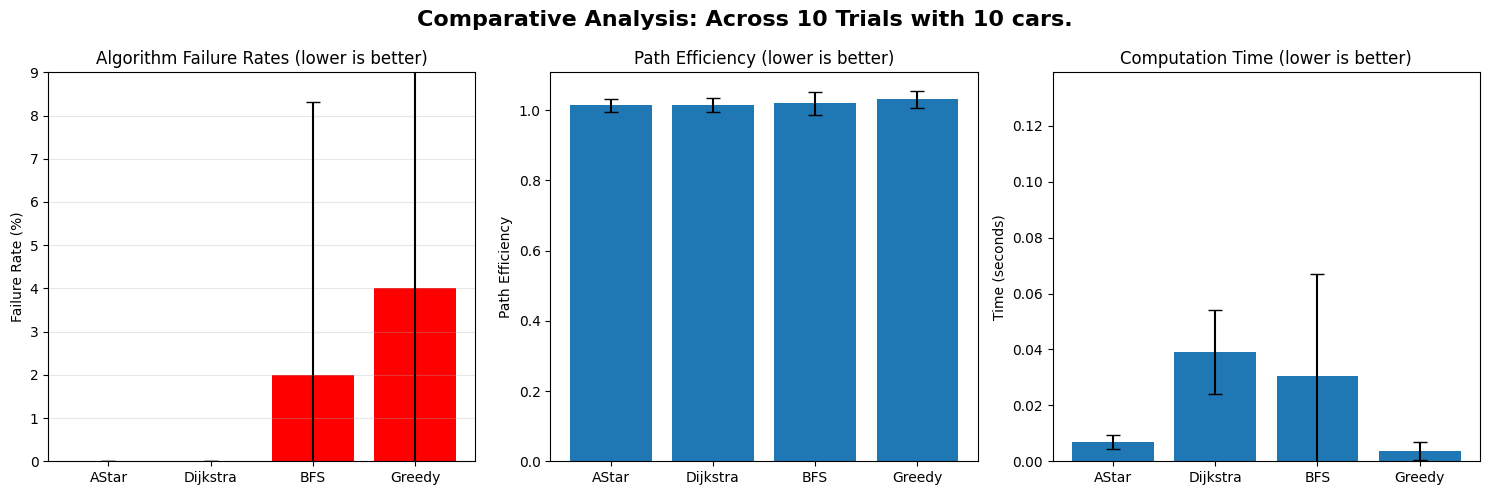

In [29]:
results, num_trials, num_cars = run_comparative_analysis(num_trials = 10, num_cars = 10, obstacle_type = 'Random')
df, num_trials, num_cars = analyse_comparative_results(results, num_trials, num_cars)

visualise_comparative_results(df, num_trials, num_cars)